# ZOMBI2 — v1 demo & test notebook

ZOMBI2 simulates **species trees backward in time** (reconstructed birth–death,
conditioned on the number of extant species) and **gene families forward in time**
(duplication / transfer / loss / origination) along that fixed tree.

The API is two symmetric steps — `simulate_species_tree(model, ...)` then
`simulate_genomes(tree, rates, ...)`. This notebook exercises the v1 core end-to-end
and doubles as a test: several cells contain `assert`s, so if anything is wrong the
notebook fails to execute.

In [1]:
import sys, pathlib
for cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (cand / "zombi2" / "__init__.py").exists():
        sys.path.insert(0, str(cand)); break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import zombi2 as z
print("zombi2", z.__version__, "| numpy", np.__version__)

zombi2 0.2.0.dev0 | numpy 2.4.0


## 1. Simulate a species tree (backward)

`Yule(birth)` is just `BirthDeath(birth, death=0)`. The root sits at time 0 and all extant leaves at `age`.

In [2]:
tree = z.simulate_species_tree(z.BirthDeath(birth=1.0, death=0.3),
                               n_tips=12, age=5.0, age_type="crown", seed=7)

print("leaves        :", len(tree.leaves()))
print("internal nodes:", len(tree.internal_nodes()))
print("root time     :", tree.root.time, "| total age:", tree.total_age)
print("ultrametric   :", all(abs(l.time - tree.total_age) < 1e-9 for l in tree.leaves()))
print()
print(tree.to_newick())

assert len(tree.leaves()) == 12
assert len(tree.internal_nodes()) == 11

leaves        : 12
internal nodes: 11
root time     : 0.0 | total age: 5.0
ultrametric   : True

((((((n10:0.2579572306,n3:0.2579572306)i5:1.40647119,(n6:1.061959681,(n8:0.6637358193,n11:0.6637358193)i7:0.3982238614)i6:0.6024687396)i4:0.1181889904,n2:1.782617411)i3:0.1491852546,n1:1.931802665)i2:0.402642028,(n7:0.3650687257,(n4:0.005170311457,n9:0.005170311457)i9:0.3598984142)i8:1.969375968)i1:2.665555307,(n12:2.569440082,n5:2.569440082)i10:2.430559918)root;


### Draw it

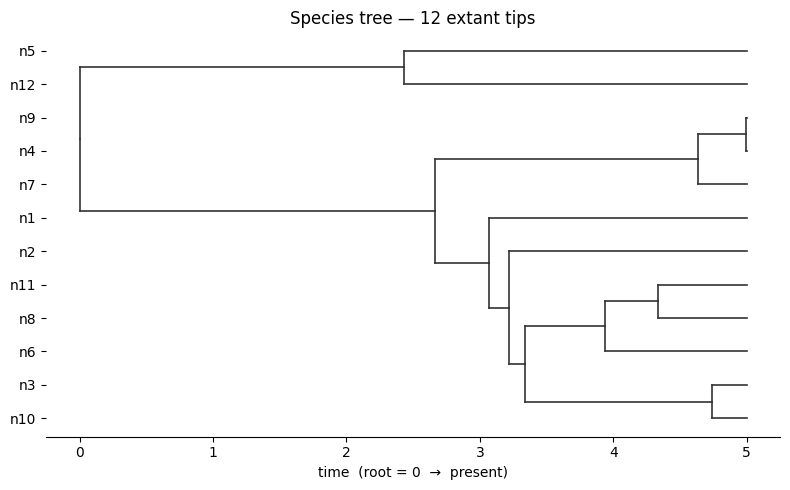

In [3]:
def plot_tree(tree, ax):
    order = [n for n in tree.nodes_preorder() if n.is_leaf()]
    y = {leaf: i for i, leaf in enumerate(order)}
    def yof(node):
        if node.is_leaf():
            return y[node]
        y[node] = float(np.mean([yof(c) for c in node.children]))
        return y[node]
    yof(tree.root)
    def draw(node):
        for c in node.children:
            ax.plot([node.time, node.time], [y[node], y[c]], color="0.2", lw=1.2)
            ax.plot([node.time, c.time], [y[c], y[c]], color="0.2", lw=1.2)
            draw(c)
    draw(tree.root)
    ax.set_yticks([y[l] for l in order]); ax.set_yticklabels([l.name for l in order])
    ax.set_xlabel("time  (root = 0  →  present)")
    ax.set_title(f"Species tree — {len(order)} extant tips")
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

fig, ax = plt.subplots(figsize=(8, 5))
plot_tree(tree, ax); plt.tight_layout(); plt.show()

### Lineages-through-time — the *pull of the present*

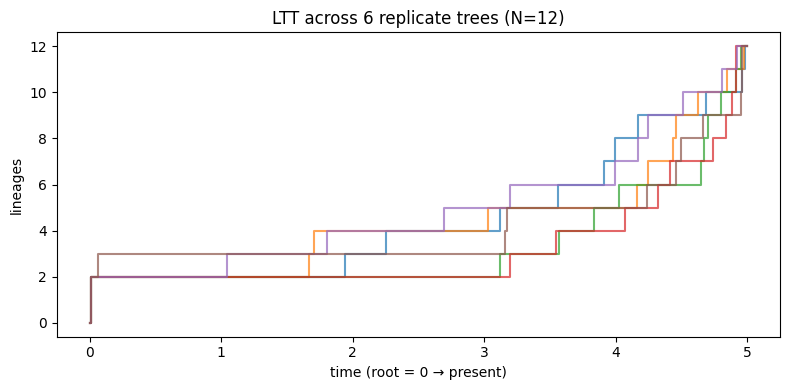

In [4]:
def ltt(tree, npts=400):
    ts = np.linspace(tree.root.time, tree.total_age, npts)
    return ts, [len(tree.branches_alive_at(t)) for t in ts]

fig, ax = plt.subplots(figsize=(8, 4))
for seed in range(6):
    t2 = z.simulate_species_tree(z.BirthDeath(1.0, 0.3), n_tips=12, age=5.0, seed=seed)
    ts, counts = ltt(t2)
    ax.step(ts, counts, where="post", alpha=0.7)
ax.set_xlabel("time (root = 0 → present)"); ax.set_ylabel("lineages")
ax.set_title("LTT across 6 replicate trees (N=12)")
plt.tight_layout(); plt.show()

## 2. Statistical validation of the backward sampler

Internal-node **ages** should follow the reconstructed birth–death CDF. We pool ages over many trees and compare empirical vs analytic (Kolmogorov–Smirnov test).

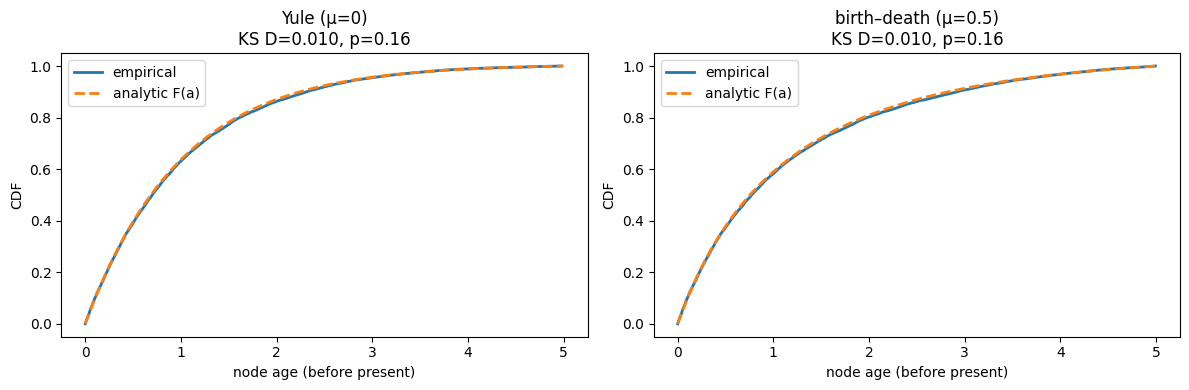

✓ sampler matches the analytic reconstructed birth–death distribution


In [5]:
from scipy import stats

def analytic_cdf(a, lam, mu, A):
    a = np.asarray(a, float); r = lam - mu
    if mu == 0:
        return (1 - np.exp(-lam * a)) / (1 - np.exp(-lam * A))
    g = lambda x: (1 - np.exp(-r * x)) / (lam - mu * np.exp(-r * x))
    return g(a) / g(A)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lam, mu, label) in zip(axes, [(1.0, 0.0, "Yule (μ=0)"), (1.0, 0.5, "birth–death (μ=0.5)")]):
    A = 5.0
    ages = []
    for s in range(400):
        tr = z.simulate_species_tree(z.BirthDeath(lam, mu), n_tips=30, age=A, age_type="stem", seed=s)
        ages.extend(tr.total_age - n.time for n in tr.internal_nodes())
    ages = np.sort(np.array(ages))
    ax.plot(ages, np.arange(1, len(ages) + 1) / len(ages), lw=2, label="empirical")
    grid = np.linspace(1e-6, A, 300)
    ax.plot(grid, analytic_cdf(grid, lam, mu, A), "--", lw=2, label="analytic F(a)")
    D, p = stats.kstest(ages, lambda x: analytic_cdf(x, lam, mu, A))
    ax.set_title(f"{label}\nKS D={D:.3f}, p={p:.2f}")
    ax.set_xlabel("node age (before present)"); ax.set_ylabel("CDF"); ax.legend()
    assert p > 1e-3, (label, p)
plt.tight_layout(); plt.show()
print("✓ sampler matches the analytic reconstructed birth–death distribution")

## 3. Gene families (forward D/T/L/O)

Every family shares the same rates here (the `UniformRates` model, via shorthand). The key output is the **phylogenetic profile matrix** (families × extant species).

In [6]:
species = z.simulate_species_tree(z.BirthDeath(birth=1.0, death=0.2), n_tips=25, age=6.0, seed=42)
genomes = z.simulate_genomes(species, duplication=0.12, transfer=0.08, loss=0.20,
                             origination=0.6, initial_size=40, seed=42)

P = genomes.profiles
print("profile matrix (families × species):", P.matrix.shape)
print("gene families :", len(P.families), "| extant species:", len(P.species))
print("total events  :", len(genomes.event_log))

from collections import Counter
print("events by type:", dict(Counter(r.event.value for r in genomes.event_log)))

profile matrix (families × species): (48, 25)
gene families : 48 | extant species: 25
total events  : 664
events by type: {'O': 64, 'L': 319, 'D': 178, 'T': 103}


### The phylogenetic profile — the σ dataset for the future Potts / DCA validation

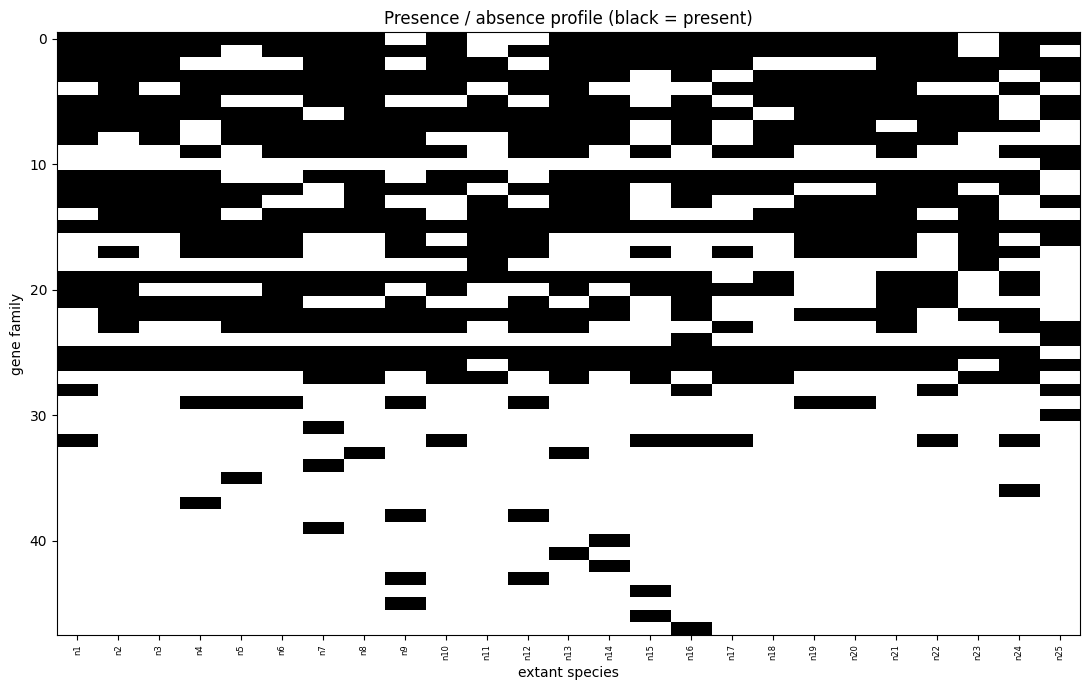

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(P.presence(), aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("extant species"); ax.set_ylabel("gene family")
ax.set_xticks(range(len(P.species))); ax.set_xticklabels(P.species, rotation=90, fontsize=6)
ax.set_title("Presence / absence profile (black = present)")
plt.tight_layout(); plt.show()

## 4. Correctness checks

In [8]:
# (a) transfer time-consistency: donor and recipient co-exist at the transfer time
name2node = {n.name: n for n in genomes.species_tree.nodes_preorder()}
n_ok = 0
for r in genomes.event_log:
    if r.event is z.EventType.TRANSFER:
        d, rc = name2node[r.donor], name2node[r.recipient]
        assert r.donor != r.recipient
        for node in (d, rc):
            assert node.parent.time < r.time <= node.time + 1e-9
        n_ok += 1
print(f"✓ transfer time-consistency: {n_ok}/{n_ok} transfers valid")

# (b) reproducibility
def run(seed):
    t = z.simulate_species_tree(z.BirthDeath(1.0, 0.2), n_tips=25, age=6.0, seed=seed)
    return t, z.simulate_genomes(t, duplication=0.12, transfer=0.08, loss=0.20,
                                 origination=0.6, initial_size=40, seed=seed)
ta, ga = run(123); tb, gb = run(123)
assert ta.to_newick() == tb.to_newick() and np.array_equal(ga.profiles.matrix, gb.profiles.matrix)
print("✓ reproducibility: identical outputs for a fixed seed")

✓ transfer time-consistency: 103/103 transfers valid
✓ reproducibility: identical outputs for a fixed seed


## 5. Per-family sampled rates (ZOMBI-1 style)

`FamilySampledRates` gives **each gene family its own** D/T/L, drawn from distributions the first time the family appears and kept for life. Distribution arguments accept a built-in, any scipy frozen distribution, or a callable `rng -> float` — and this stateful rate model runs through the *unchanged* simulator.

families with their own rates:

 64


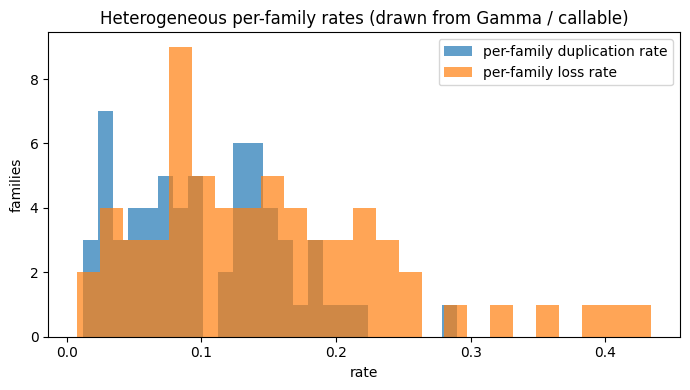

✓ a stateful per-family rate model ran through the same simulator


In [9]:
from scipy.stats import expon

fs = z.FamilySampledRates(
    duplication=z.Gamma(2, 0.06),          # built-in distribution
    transfer=expon(scale=0.06),            # scipy frozen distribution
    loss=lambda rng: rng.gamma(2, 0.07),   # a plain callable
    origination=0.6,
)
gfam = z.simulate_genomes(species, fs, initial_size=40, seed=42)

# fs now holds each family's sampled (dup, transfer, loss)
dups = [d for (d, t, l) in fs._family_rates.values()]
losses = [l for (d, t, l) in fs._family_rates.values()]
print("families with their own rates:", len(fs._family_rates))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dups, bins=25, alpha=0.7, label="per-family duplication rate")
ax.hist(losses, bins=25, alpha=0.7, label="per-family loss rate")
ax.set_xlabel("rate"); ax.set_ylabel("families"); ax.legend()
ax.set_title("Heterogeneous per-family rates (drawn from Gamma / callable)")
plt.tight_layout(); plt.show()
print("✓ a stateful per-family rate model ran through the same simulator")

## 6. Extensibility — swap the rate model, reuse everything else

The rate model emits weighted candidate events, so a **genome-wise** model (rates independent of genome size) is a one-class change running through the *unchanged* simulator, sampler and profile code.

In [10]:
class GenomeWiseRates(z.RateModel):
    """Total D/T/L rate is constant per genome (not per gene copy)."""
    def __init__(self, dup, trans, loss, orig):
        self.dup, self.trans, self.loss, self.orig = dup, trans, loss, orig
    def event_weights(self, genome, branch, time):
        out = []
        if genome.size() > 0:
            out += [z.EventWeight(z.EventType.DUPLICATION, None, self.dup),
                    z.EventWeight(z.EventType.TRANSFER,    None, self.trans),
                    z.EventWeight(z.EventType.LOSS,        None, self.loss)]
        out.append(z.EventWeight(z.EventType.ORIGINATION, None, self.orig))
        return out

gw = z.simulate_genomes(species, GenomeWiseRates(0.6, 0.4, 0.8, 0.6), initial_size=40, seed=42)
print("genome-wise → families:", len(gw.profiles.families))
print("✓ a new RateModel ran through the same simulator, sampler and profile code")

genome-wise → families: 63
✓ a new RateModel ran through the same simulator, sampler and profile code


## Summary

- The **backward** species-tree sampler reproduces the analytic reconstructed
  birth–death distribution (KS test) and shows the pull of the present.
- The **forward** D/T/L/O process yields an event log and a phylogenetic profile matrix,
  with time-consistent transfers and seed-reproducible results.
- **Rate models are the flexible knob**: `UniformRates`, per-family `FamilySampledRates`,
  and a custom genome-wise model all run through the *same* simulator — the seam the
  non-independence / Potts model will use next.